In [2]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

sys.path.append(str(Path.cwd().parent))

from src.data.features.build_features import add_lagged_returns, add_log_returns, add_log_rolling_volatility, add_rolling_z_score, add_rsi, load_prices_long
from src.data.targets.build_targets import add_volatility_target, add_direction_target
from src.models.evaluation import evaluate_predictions, walk_forward_folds, run_walk_forward

In [3]:
tickers = ['SPY','GOOG', 'NVDA', 'NFLX', 'MSFT']
df = load_prices_long("../data/raw_prices.parquet", tickers)
df.head()

Price,date,open,high,low,close,volume,ticker
0,2020-01-02,294.912997,296.143553,293.992353,296.125305,59151200,SPY
1,2020-01-03,292.743535,295.004113,292.688847,293.882935,77709700,SPY
2,2020-01-06,292.132782,295.086123,292.014280,295.004089,55653900,SPY
3,2020-01-07,294.438973,294.912981,293.727989,294.174652,40496400,SPY
4,2020-01-08,294.366059,296.954771,294.119959,295.742462,68296000,SPY


In [4]:
df = add_log_returns(df)
df = add_log_rolling_volatility(df, [5, 10, 20])
df = add_rsi(df, [14])
df = add_volatility_target(df, [5])
df.head()

Price,date,open,high,low,close,volume,ticker,log_return,vol_5d,vol_10d,vol_20d,rsi_14d,target_vol_5d
1648,2020-01-02,66.491263,67.809142,66.491263,67.770981,28132000,GOOG,NaN,NaN,NaN,NaN,NaN,-1.712450
1649,2020-01-03,66.803994,68.025229,66.689207,67.438400,23728000,GOOG,-0.004919,NaN,NaN,NaN,0.000000,-1.930775
1650,2020-01-06,66.910074,69.214751,66.910074,69.101257,34646000,GOOG,0.024358,NaN,NaN,NaN,84.336986,-2.692365
1651,2020-01-07,69.286129,69.536417,68.911427,69.058136,30054000,GOOG,-0.000624,NaN,NaN,NaN,82.396332,-2.277503
1652,2020-01-08,68.995682,69.962167,68.934228,69.602341,30560000,GOOG,0.007849,NaN,NaN,NaN,86.590143,-2.299001


In [5]:
eval_metrics = evaluate_predictions(df["target_vol_5d"], df["vol_5d"])
eval_metrics

RMSE    0.658135
MAE     0.511765
dtype: float64

test_rmse    0.5243
MAE          0.4108
dtype: float64


<Axes: title={'center': 'Train vs Test RMSE Across Folds'}, xlabel='test_start'>

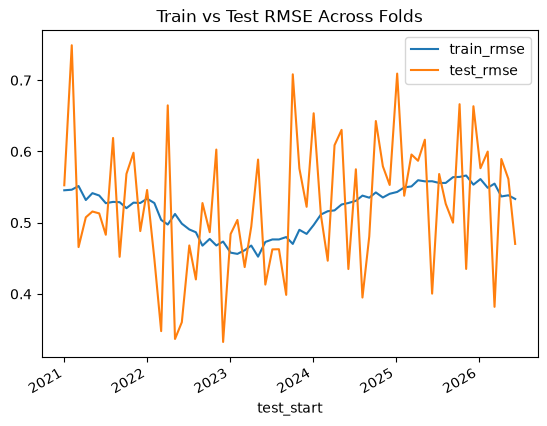

In [ ]:
feature_cols = ['vol_5d', 'vol_10d', 'vol_20d', 'rsi_14d'] 
target_col = 'target_vol_5d'

results = run_walk_forward(
    df,
    feature_cols,
    target_col,
    model_factory=lambda: LinearRegression(),
    train_size=252,
    test_size=21,
)

print(results[["test_rmse", "MAE"]].mean())

results.plot(
    x="test_start",
    y=["train_rmse", "test_rmse"],
    title="Train vs Test RMSE Across Folds",
)

In [7]:
results['train_rmse'].mean()

np.float64(0.5192212305150723)

# Model Performance & Evalaution Summary
Linear regression achieved a mean out-of-sample test RMSE of 0.5243 and MAE of 0.4012 across the walk-forward validation folds
This beat the naive baseline's test RMSE of 0.6581 and MAE of 0.5118
This means that there is a genuine predictive signal beyond a simple persistence assumption
Also the gap between the trianing RMSE (~0.45-0.57) and test RMSE remains small and centered around similar levels across folds, which confirms taht the model isn't meaningfully overfitting and the fold-fold volatility in test RMSE is primarily because of the small sample estimation variance inehrent in 21-day windows

In [8]:
def get_xgb_model():
    return XGBRegressor(
        n_estimators=100,
        learning_rate=0.03,
        max_depth=3,            # Shallow depth prevents rapid memorization of noise
        subsample=0.8,          # Row subsampling adds regularization
        colsample_bytree=0.8,   # Feature subsampling
        random_state=42,
        n_jobs=-1
    )

In [9]:
results = run_walk_forward(
    df=df,
    feature_cols=feature_cols,
    target_col='target_vol_5d',
    model_factory=get_xgb_model  
)

test_rmse    0.534179
MAE          0.417270
dtype: float64


<Axes: title={'center': 'Train vs Test RMSE Across Folds'}, xlabel='test_start'>

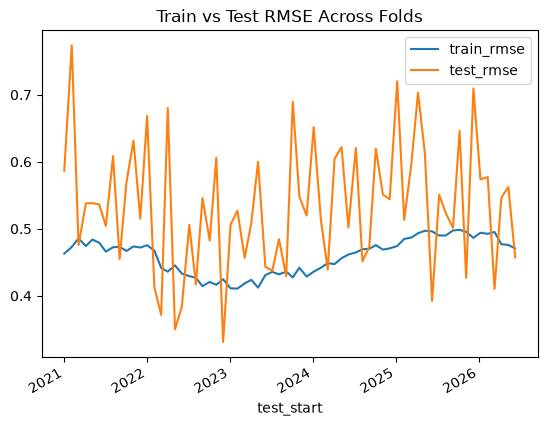

In [10]:
print(results[["test_rmse", "MAE"]].mean())

results.plot(
    x="test_start",
    y=["train_rmse", "test_rmse"],
    title="Train vs Test RMSE Across Folds",
)

In [11]:
results['train_rmse'].mean()

np.float64(0.45960512509382306)

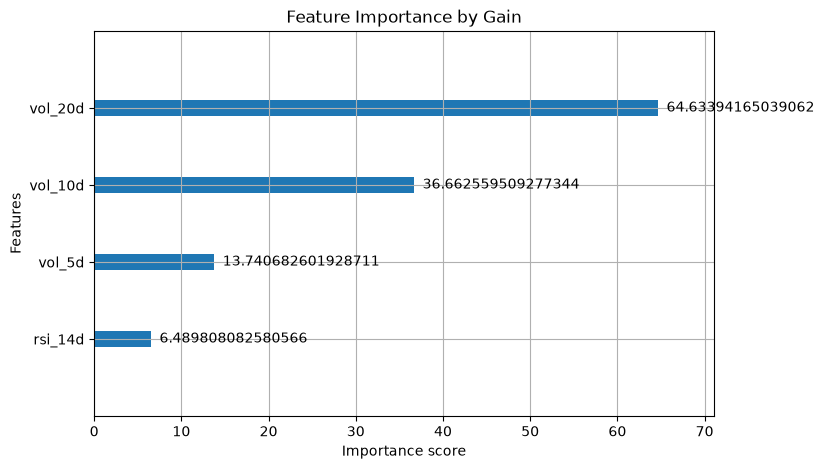

In [15]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

data = df[feature_cols + ['target_vol_5d']].dropna()

X = data[feature_cols]
y = data['target_vol_5d']

xgb_model = get_xgb_model()
xgb_model.fit(X, y)

# Plot by gain (how much each feature improves the model's accuracy)
fig, ax = plt.subplots(figsize=(8, 5))
plot_importance(xgb_model, ax=ax, importance_type='gain', max_num_features=10)
plt.title("Feature Importance by Gain")
plt.show()

XGBoost didn't outperform the linear regression baseline, which suggests that the relationship between the features and future volatility is close to linear and the added complexity isn't capturing additional signal at least with this feature set. Vol_20d and vol_10d were the most important features, which means that longer volatility windows capture the patterns better.